# Retail Sales Forecast Dataset 2026

This notebook performs EDA and builds baseline machine learning models for sales forecasting and demand classification.

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

## Find Dataset File

In [5]:
# Local: CSV junto al notebook. Kaggle Kernels: /kaggle/input/...
from pathlib import Path

roots = [Path.cwd(), Path("/kaggle/input")]
found = []
for root in roots:
    if not root.exists():
        continue
    found.extend(sorted(root.rglob("*.csv")))

print("CSV encontrados:")
for path in found:
    print(path)


CSV encontrados:
c:\Users\chuwi\Documents\culebra\data\kaggle\retail-forecast\data_dictionary.csv
c:\Users\chuwi\Documents\culebra\data\kaggle\retail-forecast\retail_sales_forecast_dataset.csv


## Load Dataset

In [6]:
from pathlib import Path

candidates = [
    Path.cwd() / "retail_sales_forecast_dataset.csv",
    Path.cwd() / "data" / "kaggle" / "retail-forecast" / "retail_sales_forecast_dataset.csv",
]

csv_path = next((c for c in candidates if c.is_file()), None)

if csv_path is None:
    for root in (Path.cwd(), Path("/kaggle/input")):
        if not root.exists():
            continue
        hits = list(root.rglob("retail_sales_forecast_dataset.csv"))
        if hits:
            csv_path = hits[0]
            break

if csv_path is None:
    raise FileNotFoundError(
        "No se encontró retail_sales_forecast_dataset.csv. "
        "Abre el notebook con cwd en data/kaggle/retail-forecast/ "
        "(en VS Code/Cursor: Notebook: Select Working Directory)."
    )

print("Dataset path:", csv_path)
df = pd.read_csv(csv_path)
print(df.shape)
df.head()


Dataset path: c:\Users\chuwi\Documents\culebra\data\kaggle\retail-forecast\retail_sales_forecast_dataset.csv
(25000, 35)


,Transaction_ID,Date,Year,Month,Week,Day,Day_Of_Week,Quarter,Store_ID,Store_Type,...,Marketing_Spend,Weather_Condition,Economic_Index,Online_Orders,Returns,Customer_Satisfaction,Shipping_Time,Supplier_Rating,Sales_Amount,Demand_Level
0,315247,2023-01-01,2023,1,52,1,Sunday,1,ST088,Convenience Store,...,1909.90,Sunny,106.40,141,0,3.50,3,3.92,597.80,Medium
1,302305,2023-01-01,2023,1,52,1,Sunday,1,ST077,Hypermarket,...,3822.59,Rainy,86.72,47,0,4.04,4,2.92,440.51,Low
2,323122,2023-01-01,2023,1,52,1,Sunday,1,ST100,Convenience Store,...,2877.94,Cloudy,96.39,180,2,3.83,3,4.85,4233.12,High
3,301379,2023-01-01,2023,1,52,1,Sunday,1,ST088,Hypermarket,...,2606.41,Sunny,115.58,184,2,4.15,3,2.90,737.02,Medium
4,315984,2023-01-01,2023,1,52,1,Sunday,1,ST039,Hypermarket,...,4114.20,Rainy,91.96,120,2,3.73,3,3.42,2481.01,High


In [7]:
df.shape

(25000, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         25000 non-null  int64  
 1   Date                   25000 non-null  object 
 2   Year                   25000 non-null  int64  
 3   Month                  25000 non-null  int64  
 4   Week                   25000 non-null  int64  
 5   Day                    25000 non-null  int64  
 6   Day_Of_Week            25000 non-null  object 
 7   Quarter                25000 non-null  int64  
 8   Store_ID               25000 non-null  object 
 9   Store_Type             25000 non-null  object 
 10  Region                 25000 non-null  object 
 11  City                   25000 non-null  object 
 12  Product_ID             25000 non-null  object 
 13  Product_Category       25000 non-null  object 
 14  Product_Subcategory    25000 non-null  object 
 15  Br

In [9]:
df.describe()

,Transaction_ID,Year,Month,Week,Day,Quarter,Units_Sold,Unit_Price,Discount_Percent,Inventory_Level,Competitor_Price,Customer_Footfall,Marketing_Spend,Economic_Index,Online_Orders,Returns,Customer_Satisfaction,Shipping_Time,Supplier_Rating,Sales_Amount
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,312500.500000,2024.503240,6.494240,26.496800,15.74960,2.499920,25.911400,105.702496,10.858600,518.685120,107.789540,474.304160,3450.418430,101.993524,151.811080,0.902120,4.094715,3.655840,3.990056,1778.815421
std,7217.022701,1.117228,3.458561,15.099181,8.80618,1.119451,15.783214,133.820833,10.070147,189.058031,137.851319,212.174949,1136.503395,6.993038,91.862642,1.175396,0.524766,1.439068,0.575691,2205.745626
min,300001.000000,2023.000000,1.000000,1.000000,1.00000,1.000000,1.000000,4.890000,0.000000,20.000000,5.160000,20.000000,100.000000,75.000000,0.000000,0.000000,1.830000,1.000000,1.670000,0.000000
25%,306250.750000,2024.000000,3.000000,13.000000,8.00000,1.000000,15.000000,25.020000,0.000000,391.000000,25.427500,325.000000,2675.792500,97.280000,93.000000,0.000000,3.740000,3.000000,3.600000,539.770000
50%,312500.500000,2025.000000,6.000000,26.000000,16.00000,2.000000,23.000000,51.460000,10.000000,519.000000,51.960000,477.000000,3477.695000,101.980000,131.000000,1.000000,4.110000,4.000000,4.000000,969.265000
75%,318750.250000,2025.000000,10.000000,40.000000,23.00000,4.000000,34.000000,113.452500,20.000000,645.000000,115.702500,622.000000,4245.772500,106.770000,177.000000,1.000000,4.470000,5.000000,4.410000,1990.995000
max,325000.000000,2026.000000,12.000000,53.000000,31.00000,4.000000,156.000000,1204.560000,35.000000,1309.000000,1326.170000,1208.000000,7866.660000,125.000000,482.000000,14.000000,5.000000,10.000000,5.000000,22816.400000


In [10]:
df.isnull().sum()

Transaction_ID           0
Date                     0
Year                     0
Month                    0
Week                     0
Day                      0
Day_Of_Week              0
Quarter                  0
Store_ID                 0
Store_Type               0
Region                   0
City                     0
Product_ID               0
Product_Category         0
Product_Subcategory      0
Brand                    0
Units_Sold               0
Unit_Price               0
Discount_Percent         0
Promotion                0
Holiday                  0
Season                   0
Inventory_Level          0
Competitor_Price         0
Customer_Footfall        0
Marketing_Spend          0
Weather_Condition        0
Economic_Index           0
Online_Orders            0
Returns                  0
Customer_Satisfaction    0
Shipping_Time            0
Supplier_Rating          0
Sales_Amount             0
Demand_Level             0
dtype: int64

## Monthly Sales Trend

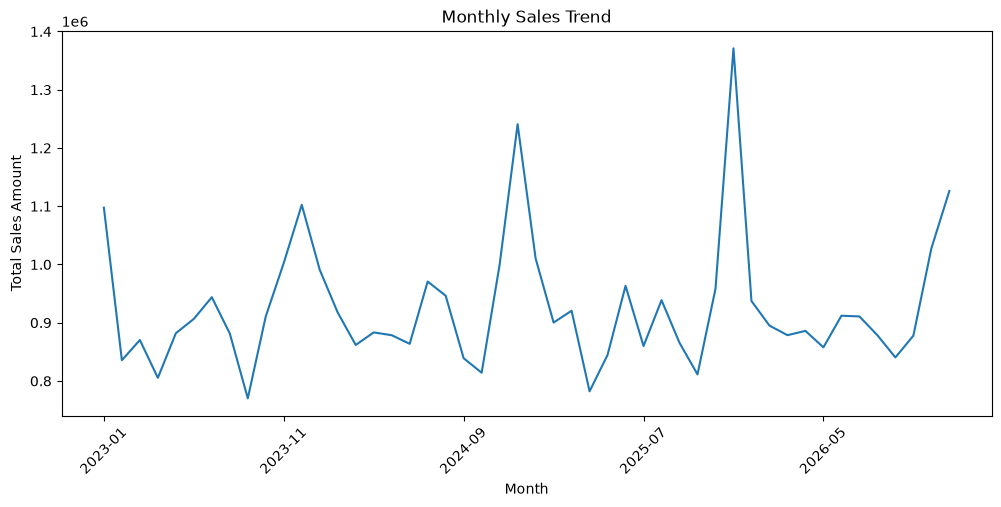

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales_Amount'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(figsize=(12, 5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.show()

## Sales by Product Category

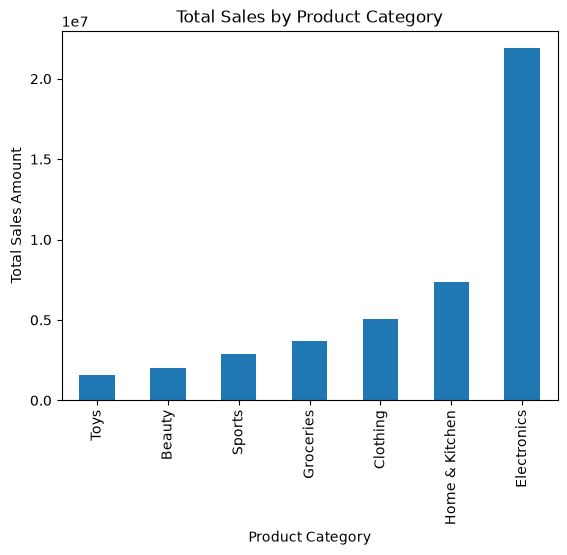

In [12]:
df.groupby('Product_Category')['Sales_Amount'].sum().sort_values().plot(kind='bar')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.show()

## Promotion Impact

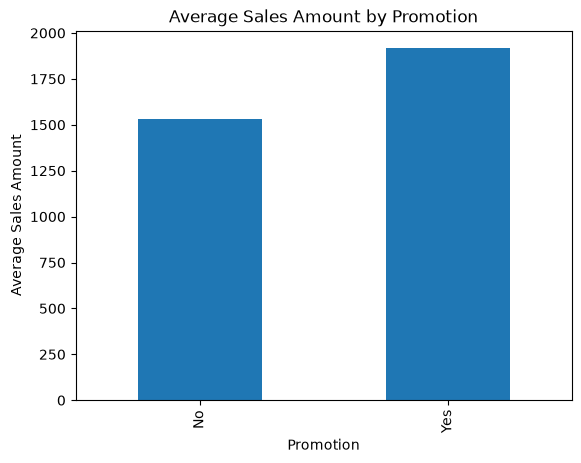

In [13]:
df.groupby('Promotion')['Sales_Amount'].mean().plot(kind='bar')
plt.title('Average Sales Amount by Promotion')
plt.xlabel('Promotion')
plt.ylabel('Average Sales Amount')
plt.show()

## Demand Level Distribution

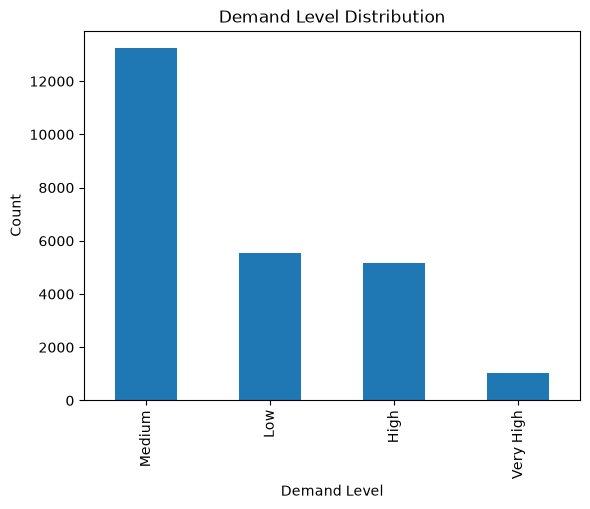

In [14]:
df['Demand_Level'].value_counts().plot(kind='bar')
plt.title('Demand Level Distribution')
plt.xlabel('Demand Level')
plt.ylabel('Count')
plt.show()

## Regression Model: Predict Sales Amount

In [15]:
X = df.drop(columns=['Transaction_ID', 'Date', 'Sales_Amount', 'Demand_Level'])
y = df['Sales_Amount']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred))
print('R2 Score:', r2_score(y_test, pred))

MAE: 96.06308093999999
R2 Score: 0.9896370225008218


## Classification Model: Predict Demand Level

In [16]:
X = df.drop(columns=['Transaction_ID', 'Date', 'Sales_Amount', 'Demand_Level'])
y = df['Demand_Level']

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8558
              precision    recall  f1-score   support

        High       0.82      0.80      0.81      1035
         Low       0.93      0.76      0.84      1110
      Medium       0.84      0.94      0.89      2646
   Very High       0.96      0.51      0.67       209

    accuracy                           0.86      5000
   macro avg       0.89      0.75      0.80      5000
weighted avg       0.86      0.86      0.85      5000



## Results and Conclusion

This analysis explored the Retail Sales Forecast Dataset 2026 and identified important business factors influencing sales performance.

Key findings include:

- Promotions increased average sales performance.
- Seasonal and holiday effects influenced customer demand.
- Product category, customer footfall, marketing spend, and inventory levels contributed to sales variation.
- Baseline machine learning models were able to predict sales amount and classify demand levels using retail features.

This dataset is suitable for sales forecasting, demand prediction, regression, classification, retail analytics, and business intelligence projects.